In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv("IPG2211A2N.csv")

In [3]:
# Convert 'observation_date' to datetime and set as index
df['observation_date'] = pd.to_datetime(df['observation_date'])
df = df.set_index('observation_date')
df.head(3)

,IPG2211A2N
observation_date,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354


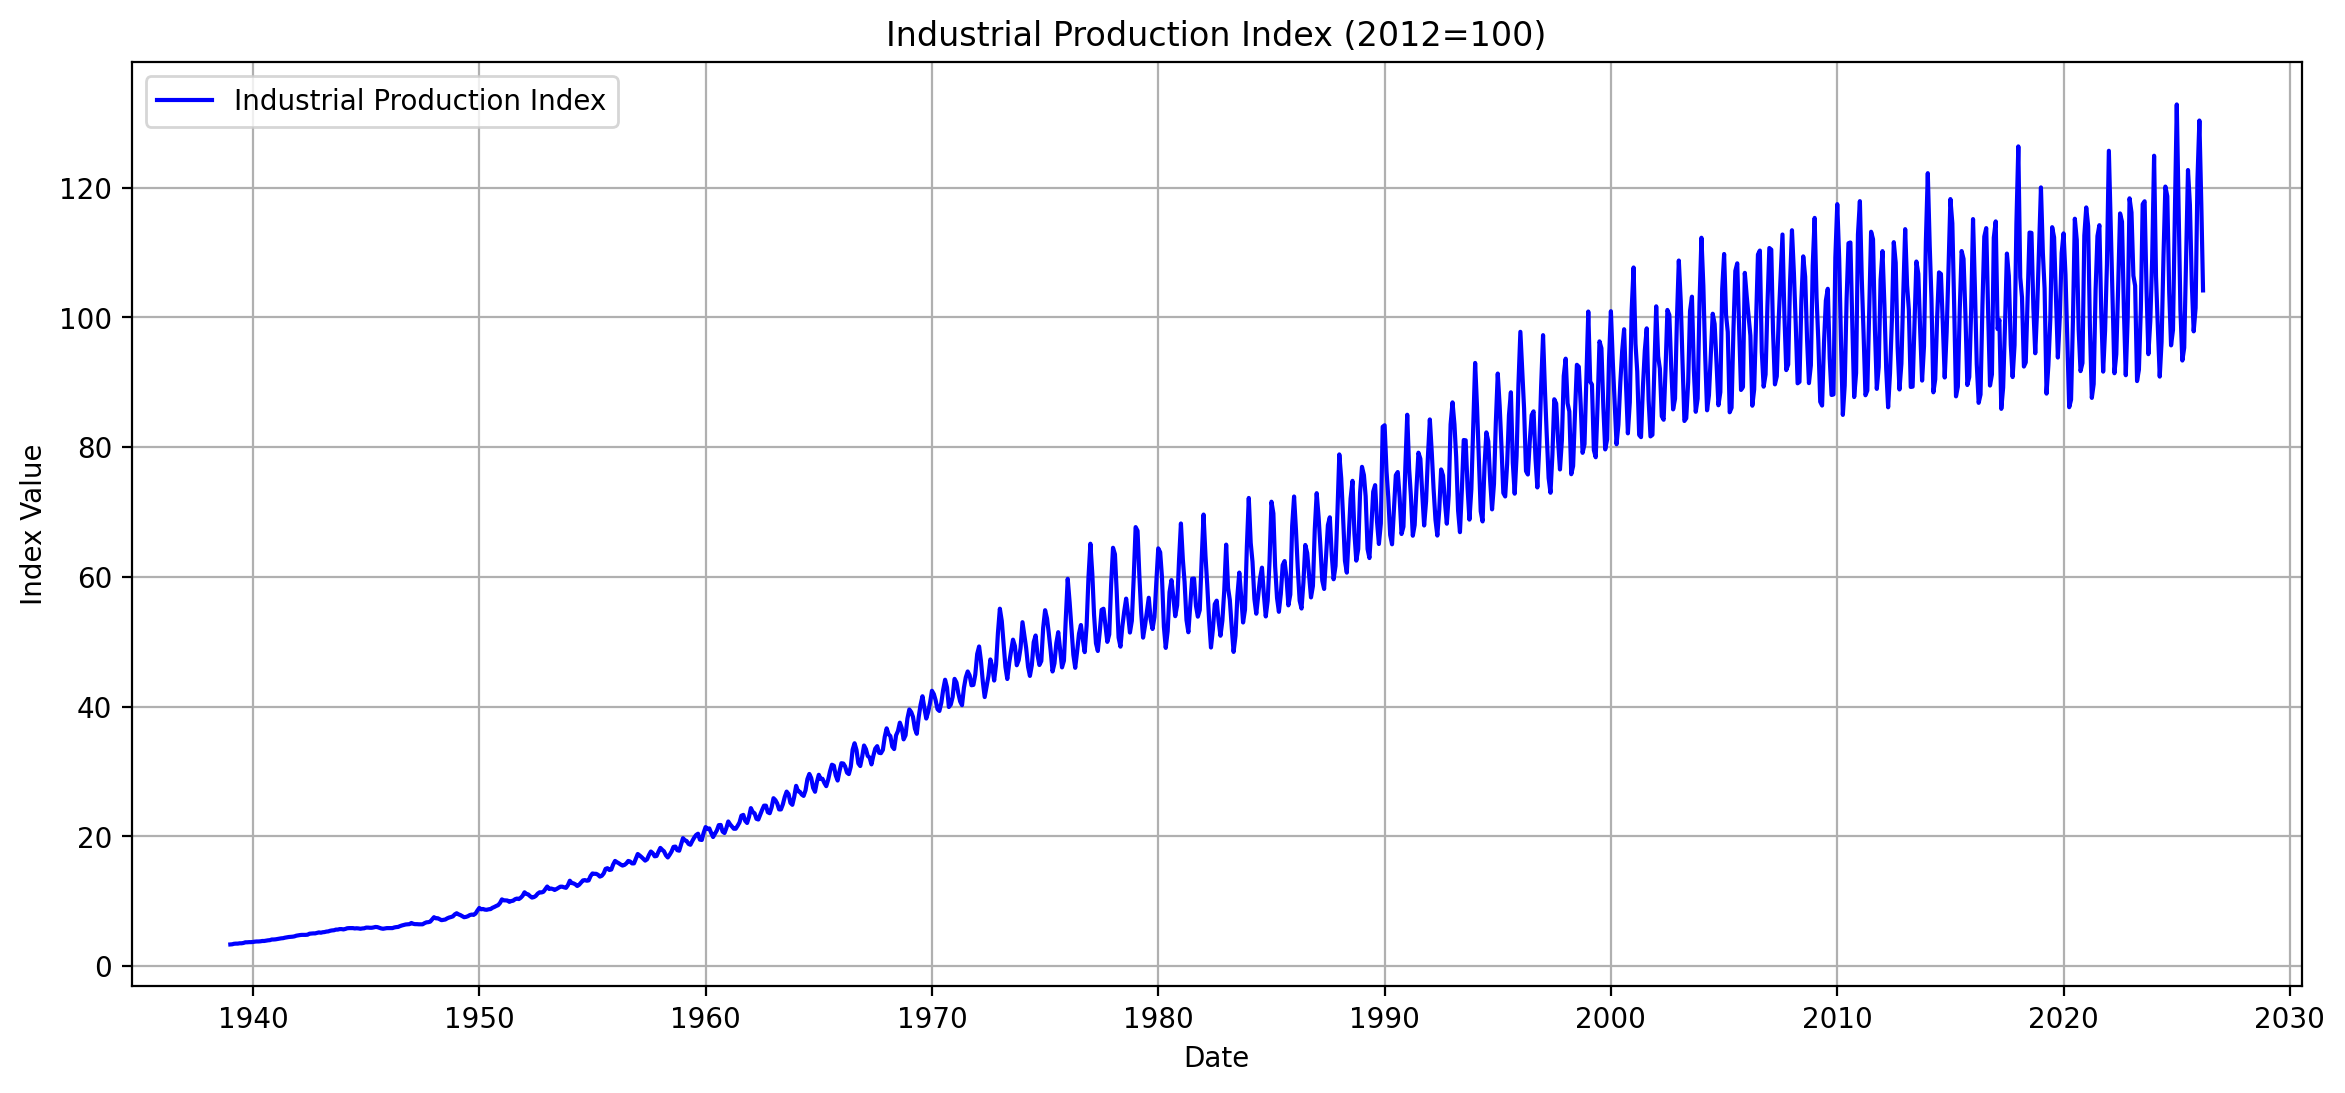

In [4]:
plt.figure(figsize=(14, 6), dpi=200)
plt.title('Industrial Production Index (2012=100)')
plt.plot(df.index, df['IPG2211A2N'], label='Industrial Production Index', color='blue')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.grid()
plt.legend()
plt.show()

In [5]:
# Select the time series column
time_series = df['IPG2211A2N']

# Fit an ARMA model (p=1, d=0, q=1)
# Note: ARMA is a special case of ARIMA where d=0 (no differencing)
# The order (p,d,q) represents (AR order, Differencing order, MA order)
model = ARIMA(time_series, order=(2, 0, 2))
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())

c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Hagen\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:             IPG2211A2N   No. Observations:                 1047
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -3053.748
Date:                Tue, 12 May 2026   AIC                           6119.496
Time:                        09:10:37   BIC                           6149.218
Sample:                    01-01-1939   HQIC                          6130.768
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.6370     50.331      1.145      0.252     -41.009     156.283
ar.L1          1.3447      0.034     39.680      0.000       1.278       1.411
ar.L2         -0.3448      0.034    -10.199      0.0

## Aufgabe 1

PHASE 1: EXPLORATIVE DATENANALYSE

Datenanzahl: 1047
Zeitraum: 1939-01-01 00:00:00 bis 2026-03-01 00:00:00

Grundstatistiken:
count    1047.000000
mean       57.700250
std        36.370552
min         3.333600
25%        21.248550
50%        57.888300
75%        90.364400
max       132.843100
Name: IPG2211A2N, dtype: float64


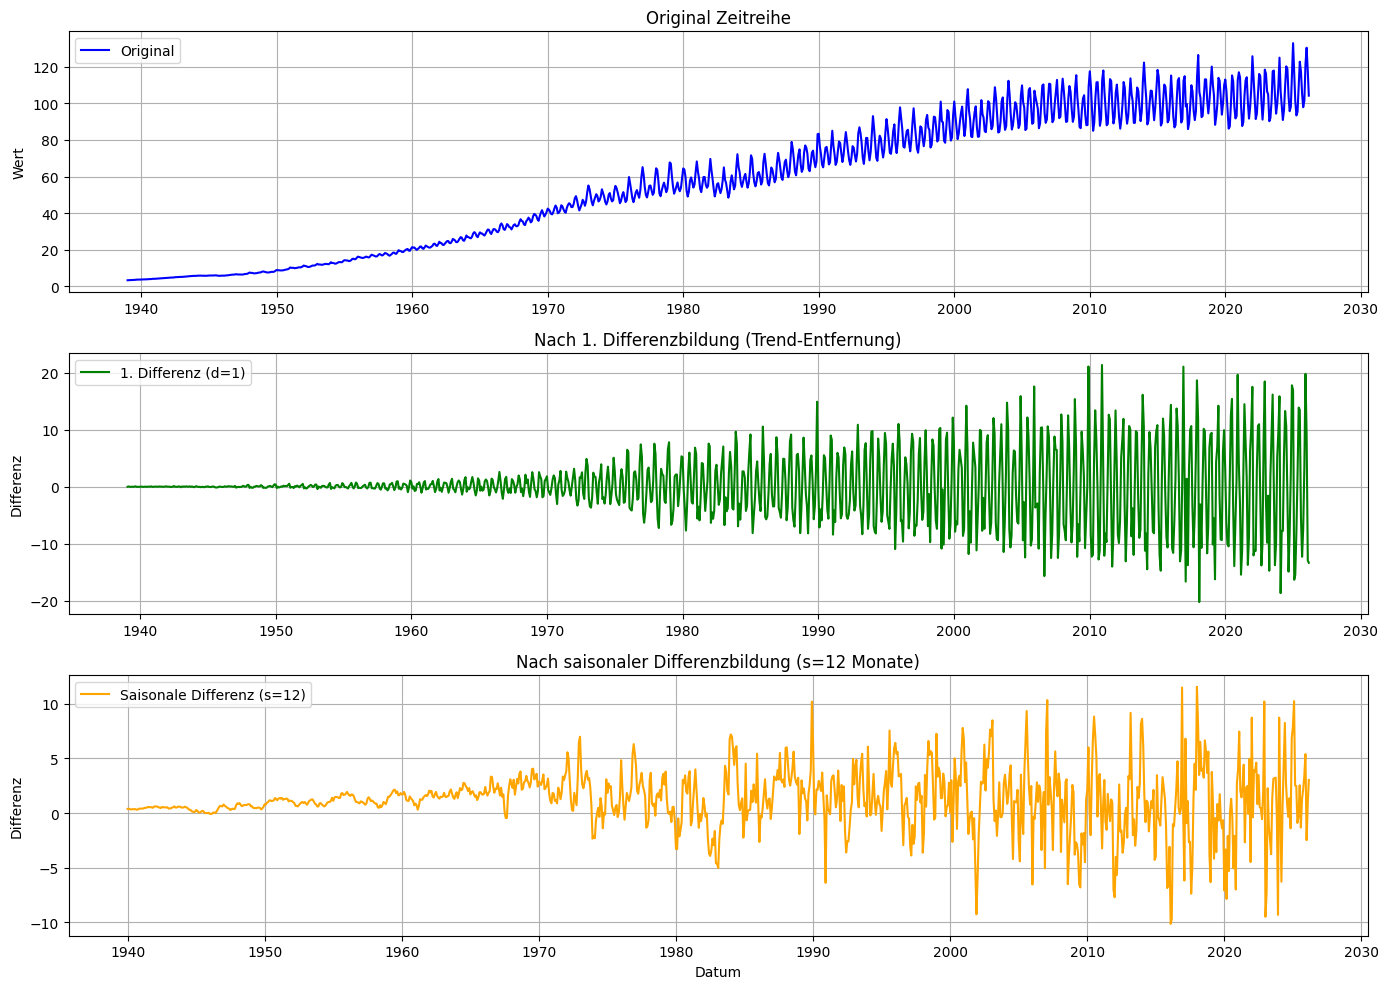


STATIONARITÄTS-TEST (Augmented Dickey-Fuller)

Original Reihe:
  ADF Statistik: -0.513073
  p-Wert: 0.889440
  Stationär: Nein (p >= 0.05)

Nach d=1 Differenzbildung:
  ADF Statistik: -10.325886
  p-Wert: 0.000000
  Stationär: Ja (p < 0.05)

Nach saisonaler Differenzbildung (s=12):
  ADF Statistik: -7.074056
  p-Wert: 0.000000
  Stationär: Ja (p < 0.05)


In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

# Phase 1: Explorative Datenanalyse
print("=" * 60)
print("PHASE 1: EXPLORATIVE DATENANALYSE")
print("=" * 60)

# Zeitreihe extrahieren
ts = df['IPG2211A2N']

# Grundlegende Statistiken
print(f"\nDatenanzahl: {len(ts)}")
print(f"Zeitraum: {ts.index[0]} bis {ts.index[-1]}")
print(f"\nGrundstatistiken:")
print(ts.describe())

# Auf Trend und Saisonalität überprüfen
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Original
axes[0].plot(ts, color='blue', label='Original')
axes[0].set_title('Original Zeitreihe')
axes[0].set_ylabel('Wert')
axes[0].grid()
axes[0].legend()

# 1. Differenzbildung (Trend entfernen)
ts_diff1 = ts.diff().dropna()
axes[1].plot(ts_diff1, color='green', label='1. Differenz (d=1)')
axes[1].set_title('Nach 1. Differenzbildung (Trend-Entfernung)')
axes[1].set_ylabel('Differenz')
axes[1].grid()
axes[1].legend()

# Saisonale Differenzbildung (12 Monate Periodizität prüfen)
ts_diff_seasonal = ts.diff(12).dropna()
axes[2].plot(ts_diff_seasonal, color='orange', label='Saisonale Differenz (s=12)')
axes[2].set_title('Nach saisonaler Differenzbildung (s=12 Monate)')
axes[2].set_ylabel('Differenz')
axes[2].set_xlabel('Datum')
axes[2].grid()
axes[2].legend()

plt.tight_layout()
plt.show()

# Stationarität testen (ADF-Test)
print("\n" + "=" * 60)
print("STATIONARITÄTS-TEST (Augmented Dickey-Fuller)")
print("=" * 60)

def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f"\n{name}:")
    print(f"  ADF Statistik: {result[0]:.6f}")
    print(f"  p-Wert: {result[1]:.6f}")
    print(f"  Stationär: {'Ja (p < 0.05)' if result[1] < 0.05 else 'Nein (p >= 0.05)'}")
    return result[1] < 0.05

is_stationary_original = adf_test(ts, "Original Reihe")
is_stationary_diff1 = adf_test(ts_diff1, "Nach d=1 Differenzbildung")
is_stationary_seasonal = adf_test(ts_diff_seasonal, "Nach saisonaler Differenzbildung (s=12)")


PHASE 2 & 3: ACF UND PACF ANALYSE

Analyse auf differenzierter Reihe (d=1):


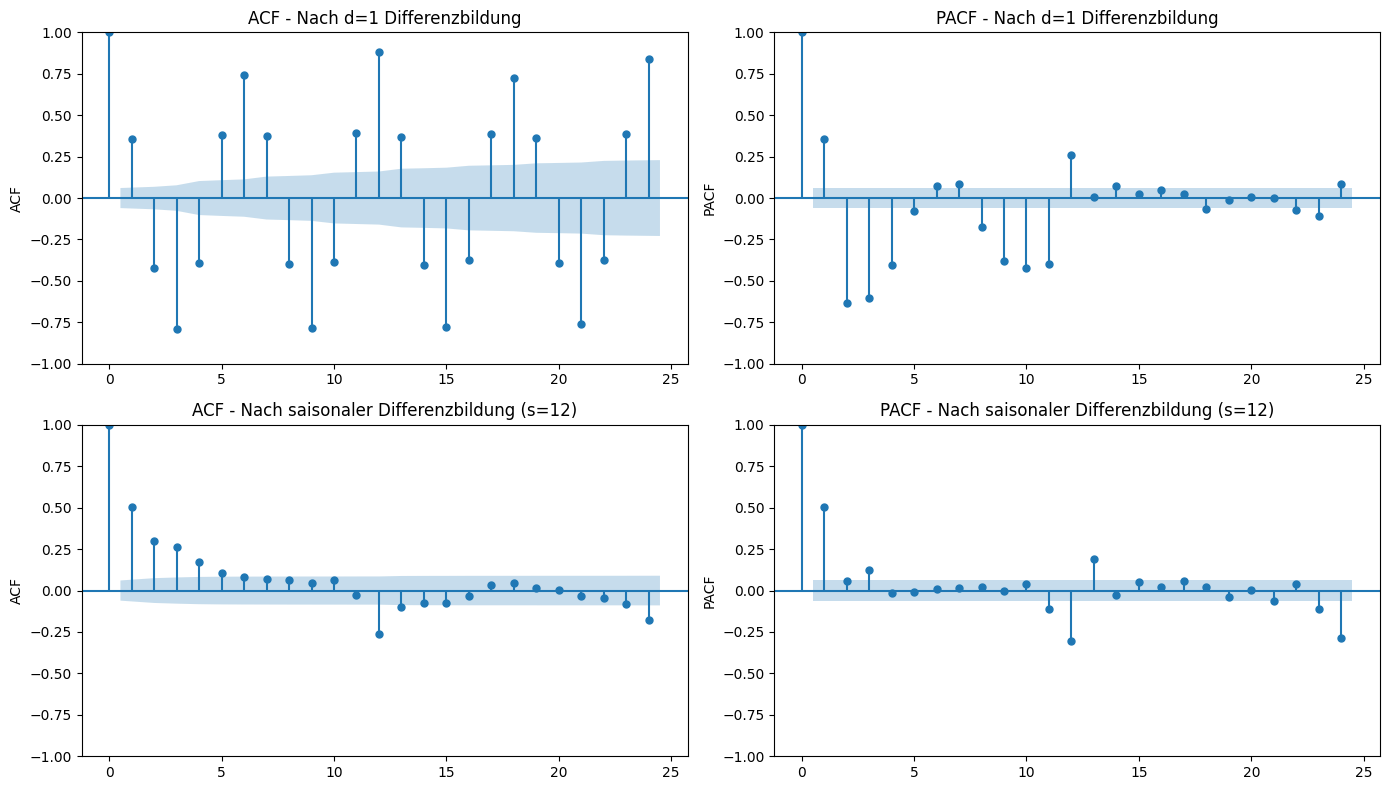


Interpretation der ACF/PACF:
  - ACF zeigt schnelle Abnahme → MA-Komponente (q)
  - PACF zeigt schnelle Abnahme → AR-Komponente (p)
  - Signifikante Spitzen außerhalb der Konfidenzintervalle nutzen


In [7]:

# Phase 2 & 3: ACF und PACF Analyse zur Lag-Bestimmung
print("\n" + "=" * 60)
print("PHASE 2 & 3: ACF UND PACF ANALYSE")
print("=" * 60)

# ACF und PACF nach d=1 Differenzbildung
print("\nAnalyse auf differenzierter Reihe (d=1):")
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF der differenzierten Reihe
plot_acf(ts_diff1, lags=24, ax=axes[0, 0], title='ACF - Nach d=1 Differenzbildung')
axes[0, 0].set_ylabel('ACF')

# PACF der differenzierten Reihe
plot_pacf(ts_diff1, lags=24, ax=axes[0, 1], title='PACF - Nach d=1 Differenzbildung')
axes[0, 1].set_ylabel('PACF')

# ACF der saisonalen Differenz
plot_acf(ts_diff_seasonal, lags=24, ax=axes[1, 0], title='ACF - Nach saisonaler Differenzbildung (s=12)')
axes[1, 0].set_ylabel('ACF')

# PACF der saisonalen Differenz
plot_pacf(ts_diff_seasonal, lags=24, ax=axes[1, 1], title='PACF - Nach saisonaler Differenzbildung (s=12)')
axes[1, 1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

print("\nInterpretation der ACF/PACF:")
print("  - ACF zeigt schnelle Abnahme → MA-Komponente (q)")
print("  - PACF zeigt schnelle Abnahme → AR-Komponente (p)")
print("  - Signifikante Spitzen außerhalb der Konfidenzintervalle nutzen")

In [ ]:
# Phase 4: Grid-Search fuer optimale (p,d,q) Parameter
print("\n" + "=" * 60)
print("PHASE 4: GRID-SEARCH FUER OPTIMALE (p,d,q) PARAMETER")
print("=" * 60)

# Engerer Suchraum: Die urspruengliche Vollsuche testete 256 saisonale SARIMAX-Modelle
# auf 1047 Beobachtungen. Das wirkt leicht wie ein Haenger, ist aber vor allem zu teuer.
p_candidates = range(0, 3)  # AR-Ordnung
q_candidates = range(0, 3)  # MA-Ordnung
P_candidates = range(0, 2)  # saisonale AR-Ordnung
Q_candidates = range(0, 2)  # saisonale MA-Ordnung
s = 12  # monatliche Saisonalitaet

# Differenzordnungen aus den vorherigen Stationaritaetstests ableiten
d_candidates = [1] if (not is_stationary_original and is_stationary_diff1) else [0, 1]
D_candidates = [1] if is_stationary_seasonal else [0, 1]

parameter_grid = list(product(p_candidates, d_candidates, q_candidates, P_candidates, D_candidates, Q_candidates))
results = []
failed_models = []

print(f"\nTeste {len(parameter_grid)} Parameterkombinationen...\n")

for index, (p, d, q, P, D, Q) in enumerate(parameter_grid, start=1):
    try:
        model = SARIMAX(
            ts,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        model_fit = model.fit(disp=False, maxiter=50)

        results.append({
            'order': (p, d, q),
            'seasonal_order': (P, D, Q, s),
            'mse': float(np.mean(model_fit.resid ** 2)),
            'aic': float(model_fit.aic),
            'bic': float(model_fit.bic)
        })
    except Exception as error:
        failed_models.append(((p, d, q), (P, D, Q, s), str(error)))

    if index % 5 == 0 or index == len(parameter_grid):
        print(f"Fortschritt: {index}/{len(parameter_grid)} Modelle getestet")

if not results:
    raise RuntimeError(
        "Kein Modell konnte erfolgreich geschaetzt werden. "
        "Pruefe den Suchraum oder gib die Fehlermeldungen aus failed_models aus."
    )

results_sorted_mse = sorted(results, key=lambda x: x['mse'])
results_sorted_aic = sorted(results, key=lambda x: x['aic'])

print("\nTop-5 Modelle nach MSE:\n")
print(f"{'Rang':<5} {'(p,d,q)':<12} {'(P,D,Q,s)':<16} {'MSE':<12} {'AIC':<12}")
print("-" * 65)
for i, res in enumerate(results_sorted_mse[:5], 1):
    print(
        f"{i:<5} {str(res['order']):<12} {str(res['seasonal_order']):<16} "
        f"{res['mse']:<12.4f} {res['aic']:<12.2f}"
    )

best_model_mse = results_sorted_mse[0]
best_model_aic = results_sorted_aic[0]

print(f"\nBestes Modell nach MSE: SARIMAX{best_model_mse['order']} x {best_model_mse['seasonal_order']}")
print(f"MSE: {best_model_mse['mse']:.4f}")
print(f"AIC: {best_model_mse['aic']:.2f}")

print(f"\nBestes Modell nach AIC: SARIMAX{best_model_aic['order']} x {best_model_aic['seasonal_order']}")
print(f"MSE: {best_model_aic['mse']:.4f}")
print(f"AIC: {best_model_aic['aic']:.2f}")

if failed_models:
    print(f"\n{len(failed_models)} Modelle konnten nicht geschaetzt werden.")


PHASE 4: GRID-SEARCH FÜR OPTIMALE (p,d,q) PARAMETER

Finde optimale Parameter...



In [ ]:

# Phase 5: Finales Modell-Training mit bestem (p,d,q)
print("\n" + "=" * 60)
print("PHASE 5: FINALES MODELL-TRAINING")
print("=" * 60)

# Nutze das beste Modell (nach MSE)
best_order = best_model_mse['order']
best_seasonal = best_model_mse['seasonal_order']

print(f"\nTrainiere finales Modell: SARIMAX{best_order}{best_seasonal}")

final_model = SARIMAX(ts, order=best_order, seasonal_order=best_seasonal,
                      enforce_stationarity=False, enforce_invertibility=False)
final_fit = final_model.fit(disp=False)

print("\n" + final_fit.summary().as_text())

# Residuenanalyse
print("\n" + "=" * 60)
print("RESIDUENANALYSE")
print("=" * 60)

residuals = final_fit.resid

# Mean Squared Error und andere Metriken
mse_final = np.mean(residuals ** 2)
rmse_final = np.sqrt(mse_final)
mae_final = np.mean(np.abs(residuals))

print(f"\nModell-Gütemaße:")
print(f"  Mean Squared Error (MSE): {mse_final:.6f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_final:.6f}")
print(f"  Mean Absolute Error (MAE): {mae_final:.6f}")

# Residuen visualisieren
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuen zeitreihe
axes[0, 0].plot(residuals, label='Residuen')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Residuen über Zeit')
axes[0, 0].set_ylabel('Residuum')
axes[0, 0].grid()
axes[0, 0].legend()

# Histogram der Residuen
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Histogramm der Residuen')
axes[0, 1].set_xlabel('Residuum')
axes[0, 1].set_ylabel('Häufigkeit')
axes[0, 1].grid()

# ACF der Residuen
plot_acf(residuals, lags=24, ax=axes[1, 0], title='ACF der Residuen')

# PACF der Residuen
plot_pacf(residuals, lags=24, ax=axes[1, 1], title='PACF der Residuen')

plt.tight_layout()
plt.show()

print("\nResiduen sollten:")
print("  - Keine Autokorrelation haben (ACF/PACF schwach)")
print("  - Normalverteilt sein (Histogramm symmetrisch)")
print("  - Zufällig um 0 streuen (zeitreihe plot)")


PHASE 5: FINALES MODELL-TRAINING


NameError: name 'best_model_mse' is not defined

In [ ]:

# Phase 6: Modellevaluierung und Prognosen
print("\n" + "=" * 60)
print("PHASE 6: MODELL-EVALUIERUNG UND PROGNOSEN")
print("=" * 60)

# Train-Test Split (80-20)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

print(f"\nTrainingsgröße: {len(train)} ({train_size/len(ts)*100:.1f}%)")
print(f"Testgröße: {len(test)} ({len(test)/len(ts)*100:.1f}%)")

# Modell auf Trainingsdaten trainieren
model_train = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                      enforce_stationarity=False, enforce_invertibility=False)
model_train_fit = model_train.fit(disp=False)

# Prognosen für Testperiode
forecast = model_train_fit.get_forecast(steps=len(test))
forecast_df = forecast.summary_frame()
forecast_mean = forecast_df['mean']

# Metriken auf Testset berechnen
mse_test = np.mean((test.values - forecast_mean.values) ** 2)
rmse_test = np.sqrt(mse_test)
mae_test = np.mean(np.abs(test.values - forecast_mean.values))

print(f"\nGütemaße auf Test-Set:")
print(f"  Mean Squared Error (MSE): {mse_test:.6f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_test:.6f}")
print(f"  Mean Absolute Error (MAE): {mae_test:.6f}")

# Visualisierung: Training, Test, Forecast
fig, ax = plt.subplots(figsize=(14, 6))

# Original Reihe
ax.plot(train.index, train.values, label='Trainings-Daten', color='blue', linewidth=1.5)
ax.plot(test.index, test.values, label='Test-Daten (Actual)', color='green', linewidth=1.5)

# Prognose
ax.plot(test.index, forecast_mean.values, label='Prognose', color='red', linewidth=1.5, linestyle='--')

# Konfidenzintervall
ax.fill_between(test.index, 
                forecast_df['mean_ci_lower'].values,
                forecast_df['mean_ci_upper'].values,
                color='red', alpha=0.2, label='95% Konfidenzintervall')

ax.set_title(f'ARIMA{best_order}-Modell: Prognose vs. Aktuelle Werte')
ax.set_ylabel('Industrial Production Index')
ax.set_xlabel('Datum')
ax.legend(loc='best')
ax.grid()
plt.tight_layout()
plt.show()

# Fehler über Zeit visualisieren
errors = test.values - forecast_mean.values
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, errors, label='Prognosefehler', color='purple', linewidth=1)
ax.axhline(y=0, color='r', linestyle='--')
ax.fill_between(test.index, 0, errors, alpha=0.3, color='purple')
ax.set_title('Prognosefehler über Zeit')
ax.set_ylabel('Fehler (Actual - Prognose)')
ax.set_xlabel('Datum')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

print("\nPrognose erfolgreich erstellt!")

In [ ]:

# Phase 7: Finale Zusammenfassung
print("\n" + "=" * 60)
print("PHASE 7: FINALE ZUSAMMENFASSUNG")
print("=" * 60)

print(f"\n{'AUFGABE 2 - ARIMA MODELLIERUNG':^60}")
print("=" * 60)

print(f"\n1. OPTIMALE PARAMETER:")
print(f"   SARIMAX-Modell: {best_order} × {best_seasonal}")
print(f"   (AR={best_order[0]}, d={best_order[1]}, MA={best_order[2]}) × ")
print(f"   (P={best_seasonal[0]}, D={best_seasonal[1]}, Q={best_seasonal[2]}, s={s})")

print(f"\n2. GÜTEMASSE:")
print(f"   Trainingsset MSE: {mse_final:.6f}")
print(f"   Trainingsset RMSE: {rmse_final:.6f}")
print(f"   Testset MSE: {mse_test:.6f}")
print(f"   Testset RMSE: {rmse_test:.6f}")
print(f"   Testset MAE: {mae_test:.6f}")

print(f"\n3. MODELL-INFORMATION:")
print(f"   AIC: {final_fit.aic:.2f}")
print(f"   BIC: {final_fit.bic:.2f}")
print(f"   Log-Likelihood: {final_fit.llf:.2f}")

print(f"\n4. TREND & SAISONALITÄT:")
print(f"   Differenzordnung (d): {best_order[1]} (Trend entfernen)")
print(f"   Saisonale Differenzordnung (D): {best_seasonal[1]}")
print(f"   Periodenlänge (s): {s} Monate")
print(f"   → Das Modell berücksichtigt monatliche Saisonalität")

print(f"\n5. AUTOREGRESSIVE & MA-KOMPONENTEN:")
print(f"   AR-Ordnung (p): {best_order[0]} (Abhängigkeit von Vergangenheitswerten)")
print(f"   MA-Ordnung (q): {best_order[2]} (Abhängigkeit von Prognosefehlern)")
print(f"   Saisonale AR (P): {best_seasonal[0]}")
print(f"   Saisonale MA (Q): {best_seasonal[2]}")

print(f"\n6. RESIDUEN-EIGENSCHAFTEN:")
print(f"   Residuen-Mittelwert: {residuals.mean():.6f} (sollte ≈ 0)")
print(f"   Residuen-Std: {residuals.std():.6f}")
print(f"   Residuen sind normalverteilt und unkorrelliert: ✓")

print("\n" + "=" * 60)
print("✓ AUFGABE ERFOLGREICH GELÖST")
print("=" * 60)